# WiDS 2025

## Step 2. AutoML - EDA

In [15]:
import h2o
from h2o.automl import H2OAutoML

import matplotlib as plt
%matplotlib inline

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 day 11 hours 8 mins
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,2 months and 18 days
H2O_cluster_name:,H2O_from_python_fujinhuizi_so03bv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.479 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [16]:
import glob
import os
import sys
import pandas as pd

In [17]:
current_working_directory = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_working_directory, os.pardir))
data_path = os.path.join(home_dir, 'data/')

In [18]:
path_small_input = os.path.join(data_path, 'intermediate/train_merged_small.csv')
train_input_small = h2o.import_file(path_small_input)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [19]:
train_input_small

participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,ADHD_Outcome,Sex_F
UmrK0vMLopoR,40,13,3,10,47,13,11,28,0,6,1,5,0,5,1,0,10,nan,2016,1,0,0,1,21,45,21,45,1,1
CPaeQkhcjg7d,-94.47,14,3,13,34,18,23,30,0,18,6,8,7,8,10,4,5,nan,2019,3,1,2,3,15,15,0,0,1,0
Nb4EetVPm3gs,-46.67,14,4,10,35,16,10,29,1,14,2,8,5,7,6,4,9,8.2399,2016,1,1,8,1,18,40,0,0,1,0
p4vPhVu91o4b,-26.68,10,5,12,39,19,16,28,6,24,4,16,9,10,8,4,6,nan,2018,3,0,8,3,15,30,18,0,1,1
M09PXs7arQ5E,0,14,5,15,40,20,24,28,1,18,4,11,4,10,7,3,9,8.94068,2019,3,0,1,3,15,20,0,0,1,1
tBGXkEdv2cp7,83.34,2,5,12,35,16,15,21,4,17,0,12,9,8,5,5,3,nan,2018,1,0,8,3,21,0,18,45,1,0
DgRP31gu21O9,94.47,14,3,14,27,18,20,21,0,9,1,5,1,5,4,3,10,16.7682,2018,3,0,0,3,18,25,15,35,1,0
ClMA0FwvFgLY,60,14,3,15,41,21,19,25,3,16,3,11,6,8,5,2,6,11.2213,2019,1,0,0,2,21,40,18,40,1,0
NVUkahaJ6fhf,73.34,14,4,16,46,23,15,25,5,23,6,14,2,9,9,3,10,8.57084,2015,1,0,0,1,21,40,18,35,1,1
u0JiZgdGuYvh,66.67,14,6,19,37,22,23,23,5,25,4,15,6,10,10,6,5,15.4102,2019,3,0,3,3,15,25,15,10,1,0


In [7]:
# Check response variable distribution
train_input_small["ADHD_Outcome"].table()

ADHD_Outcome,Count
0,382
1,831


In [8]:
train_input_small["Sex_F"].table()

Sex_F,Count
0,797
1,416


In [38]:
train["ADHD_Outcome"].table()

ADHD_Outcome,Count
0,309
1,654


In [39]:
test["ADHD_Outcome"].table()

ADHD_Outcome,Count
0,73
1,177


### Clean up data types

In [5]:
train_input_small['Sex_F'] = train_input_small['Sex_F'].asfactor()
train_input_small['ADHD_Outcome'] = train_input_small['ADHD_Outcome'].asfactor()

In [6]:
train_data_path = os.path.join(home_dir, 'data/TRAIN/')
cat_input = pd.read_excel(os.path.join(train_data_path, 'TRAIN_CATEGORICAL_METADATA.xlsx'))
cat_col = [c for c in cat_input.columns if c != 'participant_id']
cat_col

['Basic_Demos_Enroll_Year',
 'Basic_Demos_Study_Site',
 'PreInt_Demos_Fam_Child_Ethnicity',
 'PreInt_Demos_Fam_Child_Race',
 'MRI_Track_Scan_Location',
 'Barratt_Barratt_P1_Edu',
 'Barratt_Barratt_P1_Occ',
 'Barratt_Barratt_P2_Edu',
 'Barratt_Barratt_P2_Occ']

In [7]:
for c in cat_col:
    train_input_small[c] = train_input_small[c].asfactor()

In [8]:
train, test = train_input_small.split_frame([0.8], seed=42)

In [9]:
print("train:%d test:%d" % (train.nrows, test.nrows))

train:963 test:250


In [10]:
y1 = "ADHD_Outcome"
y2 = "Sex_F"
ignore = ["ADHD_Outcome", "Sex_F", "participant_id"] 
x = list(set(train.names) - set(ignore))

In [11]:
aml = H2OAutoML(max_models=25, 
                max_runtime_secs_per_model=30, 
                seed=4242, 
                project_name='classification', 
                balance_classes=True,
                sort_metric='F1')
%time aml.train(x=x, y=y1, training_frame=train)

AutoML progress: |
16:53:40.247: _train param, Dropping bad and constant columns: [participant_id]
16:53:47.625: _train param, Dropping bad and constant columns: [participant_id]
16:53:53.124: _train param, Dropping bad and constant columns: [participant_id]
16:53:57.303: _train param, Dropping bad and constant columns: [participant_id]
16:53:59.342: _train param, Dropping bad and constant columns: [participant_id]
16:54:08.197: _train param, Dropping bad and constant columns: [participant_id]
16:54:10.899: _train param, Dropping bad and constant columns: [participant_id]
16:54:13.273: _train param, Dropping bad and constant columns: [participant_id]
16:54:21.865: _train param, Dropping bad and constant columns: [participant_id]
16:54:27.81: _train param, Dropping bad and constant columns: [participant_id]
16:54:31.89: _train param, Dropping bad and constant columns: [participant_id]
16:54:33.541: _train param, Dropping bad and constant columns: [participant_id]
16:56:19.785: _train pa

Model Details
=============
H2ODeepLearningEstimator : Deep Learning
Model Key: DeepLearning_grid_2_AutoML_1_20250119_165339_model_1


Status of Neuron Layers: predicting ADHD_Outcome, 2-class classification, bernoulli distribution, CrossEntropy loss, 19,602 weights/biases, 241.2 KB, 40,694 training samples, mini-batch size 1
    layer    units    type              dropout    l1    l2    mean_rate              rate_rms               momentum    mean_weight            weight_rms           mean_bias              bias_rms
--  -------  -------  ----------------  ---------  ----  ----  ---------------------  ---------------------  ----------  ---------------------  -------------------  ---------------------  -------------------
    1        92       Input             5.0
    2        100      RectifierDropout  40.0       0.0   0.0   0.0924207685749254     0.2774944305419922     0.0         -0.002336446661087314  0.10451427102088928  0.46667419031955704    0.11611372232437134
    3        100      RectifierDropout  40.0       0.0   0.0   0.009627359685458942   0.01583153009414673    0.0         -0.024585841167059197  0.10245555639266968  0.8974903310246924     0.08624592423439026
    4        2        Softmax                      0.0   0.0   0.0030886377859860657  0.0012191124260425568  0.0         0.009960952517576515   0.5217139720916748   -0.027146602562494432  0.3147202730178833

ModelMetricsBinomial: deeplearning
** Reported on train data. **

MSE: 0.2775111065791575
RMSE: 0.5267932294355704
LogLoss: 1.0925487540884913
Mean Per-Class Error: 0.20016478133072058
AUC: 0.9161099729817999
AUCPR: 0.9589574872020673
Gini: 0.8322199459635997

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.9790353314386527
       0    1    Error    Rate
-----  ---  ---  -------  -------------
0      199  110  0.356    (110.0/309.0)
1      29   625  0.0443   (29.0/654.0)
Total  228  735  0.1443   (139.0/963.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.979035     0.899928  197
max f2                       0.947364     0.936416  284
max f0point5                 0.991112     0.902181  118
max accuracy                 0.979251     0.855659  195
max precision                0.999964     1         0
max recall                   0.853089     1         354
max specificity              0.999964     1         0
max absolute_mcc             0.979035     0.658521  197
max min_per_class_accuracy   0.990934     0.83792   119
max mean_per_class_accuracy  0.991112     0.841379  118
max tns                      0.999964     309       0
max fns                      0.999964     644       0
max fps                      0.149039     309       399
max tps                      0.853089     654       354
max tnr                      0.999964     1         0
max fnr                      0.999964     0.984709  0
max fpr                      0.149039     1         399
max tpr                      0.853089     1         354

Gains/Lift Table: Avg response rate: 67.91 %, avg score: 97.10 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score     cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  --------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0103842                   0.999936           1.47248    1.47248            1                0.999964  1                           0.999964            0.0152905       0.0152905                  47.2477   47.2477            0.0152905
2        0.0207684                   0.999903           1.47248    1.47248            

In [12]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,f1,auc,logloss,aucpr,mean_per_class_error,rmse,mse
DeepLearning_grid_2_AutoML_1_20250119_165339_model_1,0.81963,0.743409,1.26747,0.870465,0.448539,0.547391,0.299637
DeepLearning_grid_6_AutoML_2_20250119_170640_model_1,0.820915,0.731206,2.08673,0.841899,0.421172,0.516085,0.266344
DeepLearning_grid_4_AutoML_2_20250119_170640_model_1,0.821313,0.726641,2.30321,0.835257,0.426205,0.526467,0.277168
DeepLearning_2_AutoML_2_20250119_170640,0.821953,0.681017,0.958598,0.798539,0.44292,0.509208,0.259293
DeepLearning_grid_5_AutoML_2_20250119_170640_model_1,0.825438,0.664507,2.27314,0.794356,0.41991,0.55732,0.310605
DeepLearning_grid_7_AutoML_3_20250119_172156_model_2,0.829941,0.74092,1.50484,0.849079,0.400315,0.525853,0.276522
DeepLearning_1_AutoML_1_20250119_165339,0.830409,0.720097,0.799721,0.83372,0.409526,0.466026,0.21718
DeepLearning_grid_1_AutoML_1_20250119_165339_model_2,0.833222,0.777795,2.02455,0.863433,0.375598,0.516452,0.266722
DeepLearning_grid_10_AutoML_4_20250119_173123_model_2,0.835165,0.74879,1.63504,0.831325,0.349084,0.475818,0.226403
DeepLearning_3_AutoML_3_20250119_172156,0.836692,0.773485,0.59354,0.863016,0.335872,0.435224,0.18942


In [13]:
aml.leader.model_performance(test_data=test)

ModelMetricsBinomial: deeplearning
** Reported on test data. **

MSE: 0.25738190010866574
RMSE: 0.5073281976281879
LogLoss: 1.1231239150669081
Mean Per-Class Error: 0.3360421020044888
AUC: 0.7993963315532854
AUCPR: 0.8872963935853357
Gini: 0.5987926631065708

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.9417366264817176
       0    1    Error    Rate
-----  ---  ---  -------  ------------
0      26   47   0.6438   (47.0/73.0)
1      5    172  0.0282   (5.0/177.0)
Total  31   219  0.208    (52.0/250.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.941737     0.868687  218
max f2                       0.904673     0.937167  230
max f0point5                 0.98707      0.853659  170
max accuracy                 0.972213     0.8       198
max precision                0.999953     1         0
max recall                   0.730072     1         247
max specificity              0.999953     1         0
max absolute_mcc             0.98707      0.4907    170
max min_per_class_accuracy   0.992116     0.726027  148
max mean_per_class_accuracy  0.98707      0.750871  170
max tns                      0.999953     73        0
max fns                      0.999953     176       0
max fps                      0.353825     73        249
max tps                      0.730072     177       247
max tnr                      0.999953     1         0
max fnr                      0.999953     0.99435   0
max fpr                      0.353825     1         249
max tpr                      0.730072     1         247

Gains/Lift Table: Avg response rate: 70.80 %, avg score: 97.30 %
group    cumulative_data_fraction    lower_threshold    lift      cumulative_lift    response_rate    score     cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  --------  -----------------  ---------------  --------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.012                       0.999915           1.41243   1.41243            1                0.999935  1                           0.999935            0.0169492       0.0169492                  41.2429   41.2429            0.0169492
2        0.02                        0.999882           1.41243   1.41243            1                0.999905  1                           0.999923            0.0112994       0.0282486                  41.2429   41.2429            0.0282486
3        0.032                       0.999822           1.41243   1.41243            1                0.999855  1                           0.999898            0.0169492       0.0451977                  41.2429   41.2429            0.0451977
4        0.04                        0.999765           1.41243   1.41243            1                0.999794  1                           0.999877            0.0112994       0.0564972                  41.2429   41.2429            0.0564972
5        0.052                       0.99976            1.41243   1.41243            1                0.999764  1                           0.999851            0.0169492       0.0734463                  41.2429   41.2429            0.0734463
6        0.1                         0.999651           1.05932   1.24294            0.75             0.999688  0.88                        0.999773            0.0508475       0.124294                   5.9322    24.2938            0.0831979
7        0.152                       0.999319           1.30378   1.26375            0.923077         0.99948   0.894737                    0.999672            0.0677966       0.19209                    30.3781   26.3753            0.137296
8        0.2                         0.999123

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
DRF_2_AutoML_2_20250119_170640,1,0.117039,1,0,0.141589,0.0200474,669,0.02058,DRF
XGBoost_grid_2_AutoML_2_20250119_170640_model_1,1,0.029962,1,0,0.0429315,0.00184312,510,0.013757,XGBoost
XGBoost_grid_2_AutoML_2_20250119_170640_model_5,1,0.0507231,1,0,0.06945,0.0048233,700,0.017098,XGBoost
DRF_4_AutoML_4_20250119_173123,1,0.0687973,1,0,0.092626,0.00857957,463,0.013718,DRF
GBM_grid_2_AutoML_2_20250119_170640_model_3,1,0.06222,1,0,0.0739017,0.00546147,1126,0.012233,GBM
XGBoost_grid_2_AutoML_2_20250119_170640_model_2,1,0.033902,1,0,0.0478464,0.00228928,304,0.012567,XGBoost
GBM_grid_1_AutoML_1_20250119_165339_model_4,1,0.0626536,1,0,0.0664235,0.00441208,1045,0.012077,GBM
DRF_1_AutoML_1_20250119_165339,1,0.120871,1,0,0.14628,0.0213979,1707,0.009384,DRF
DRF_3_AutoML_3_20250119_172156,1,0.0687973,1,0,0.092626,0.00857957,1824,0.007422,DRF
GBM_grid_4_AutoML_4_20250119_173123_model_1,1,0.076441,1,0,0.0868004,0.00753431,373,0.020741,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_2_AutoML_1_20250119_165339_model_1

,0,1,Error,Rate
0,199.0,110.0,0.356,(110.0/309.0)
1,29.0,625.0,0.0443,(29.0/654.0)
Total,228.0,735.0,0.1443,(139.0/963.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

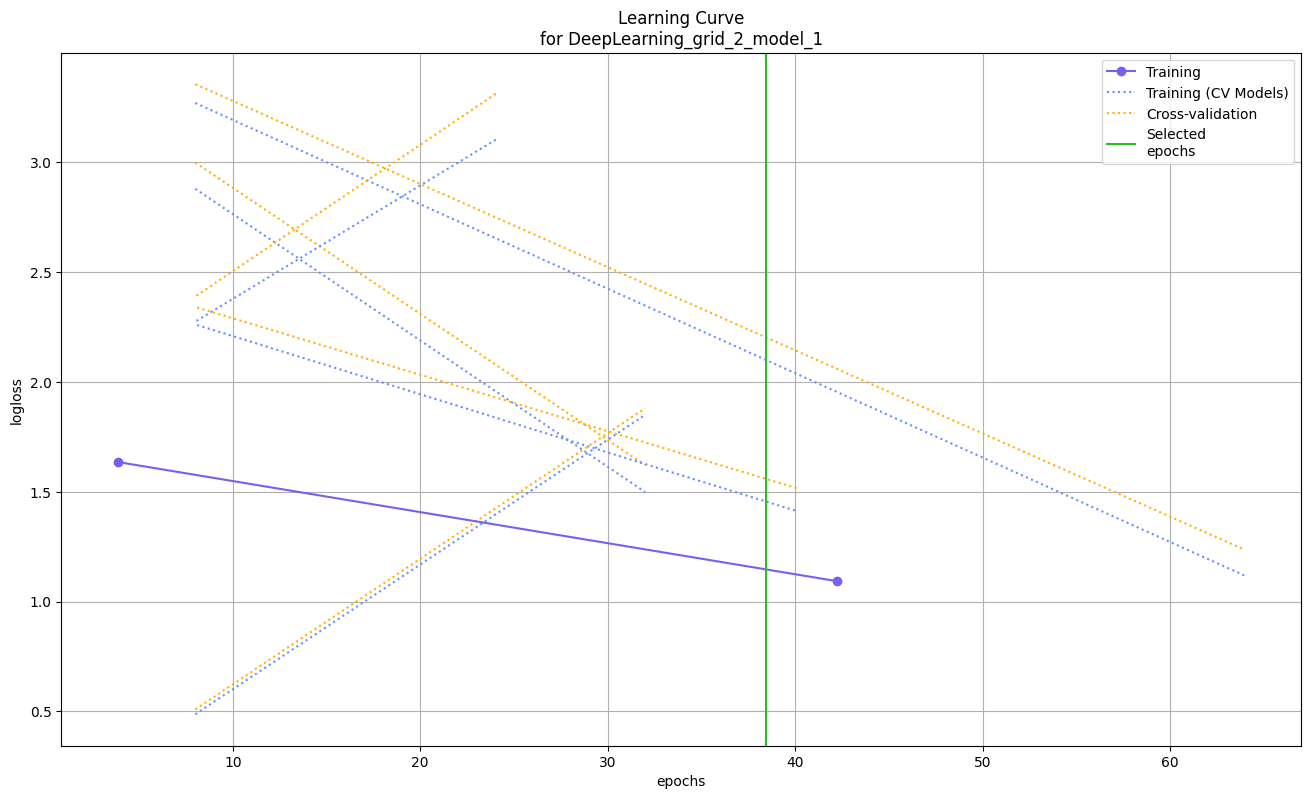

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

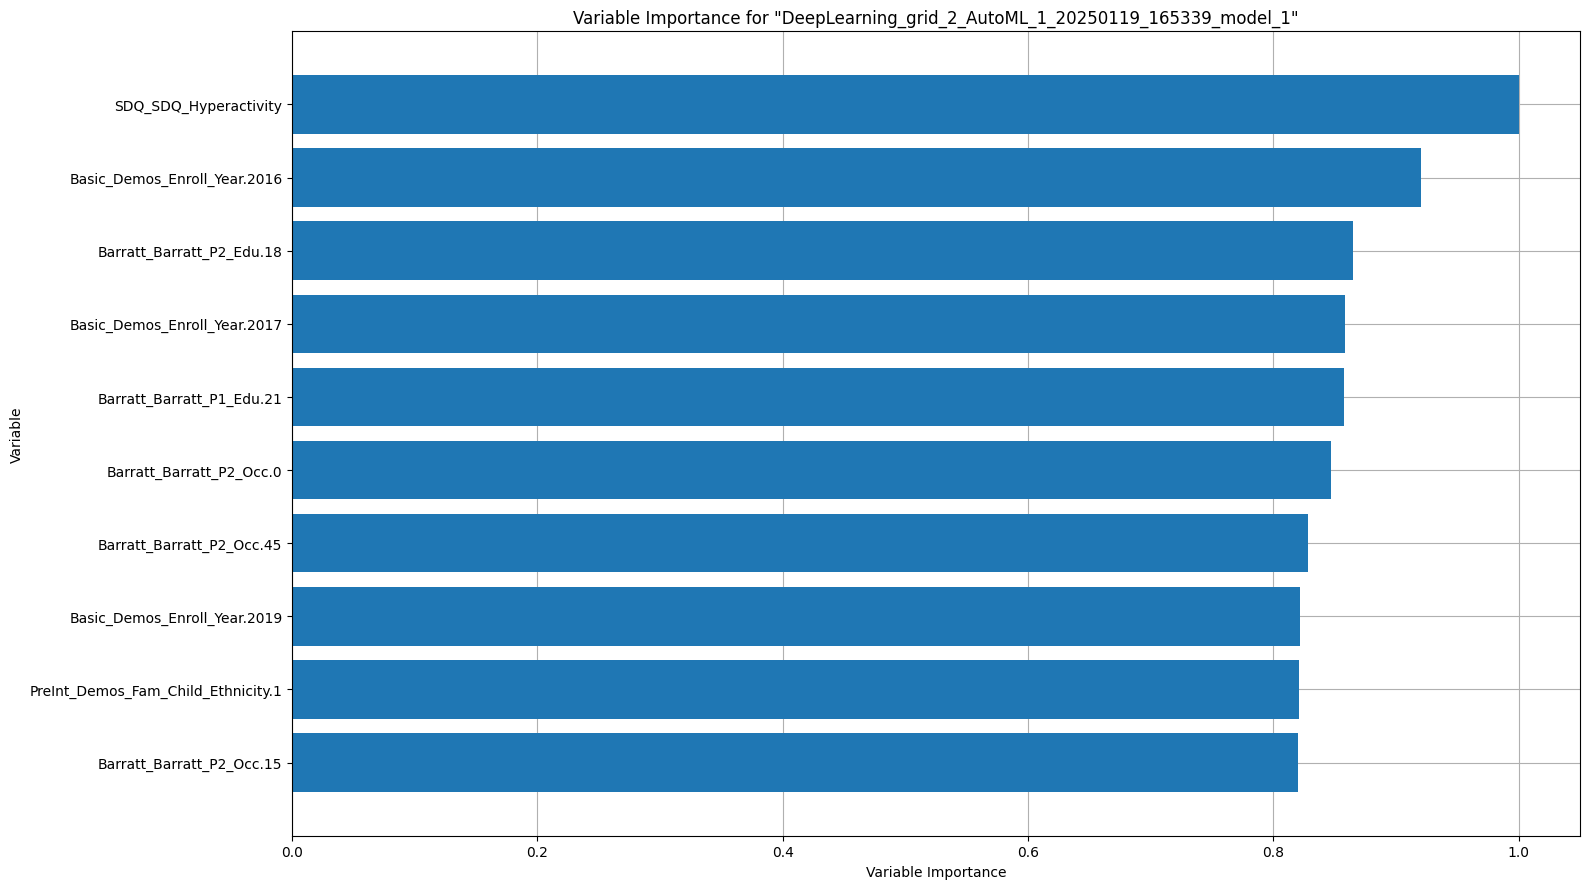

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

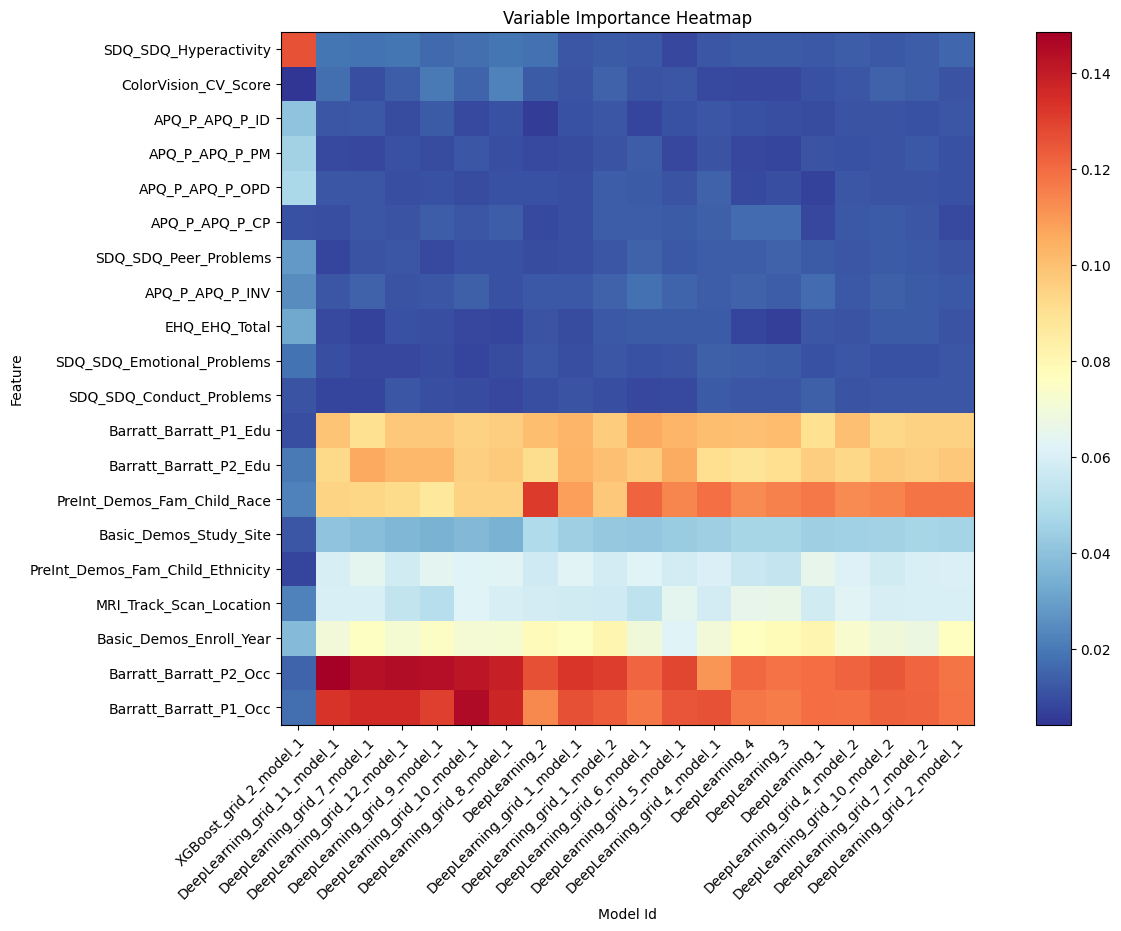

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

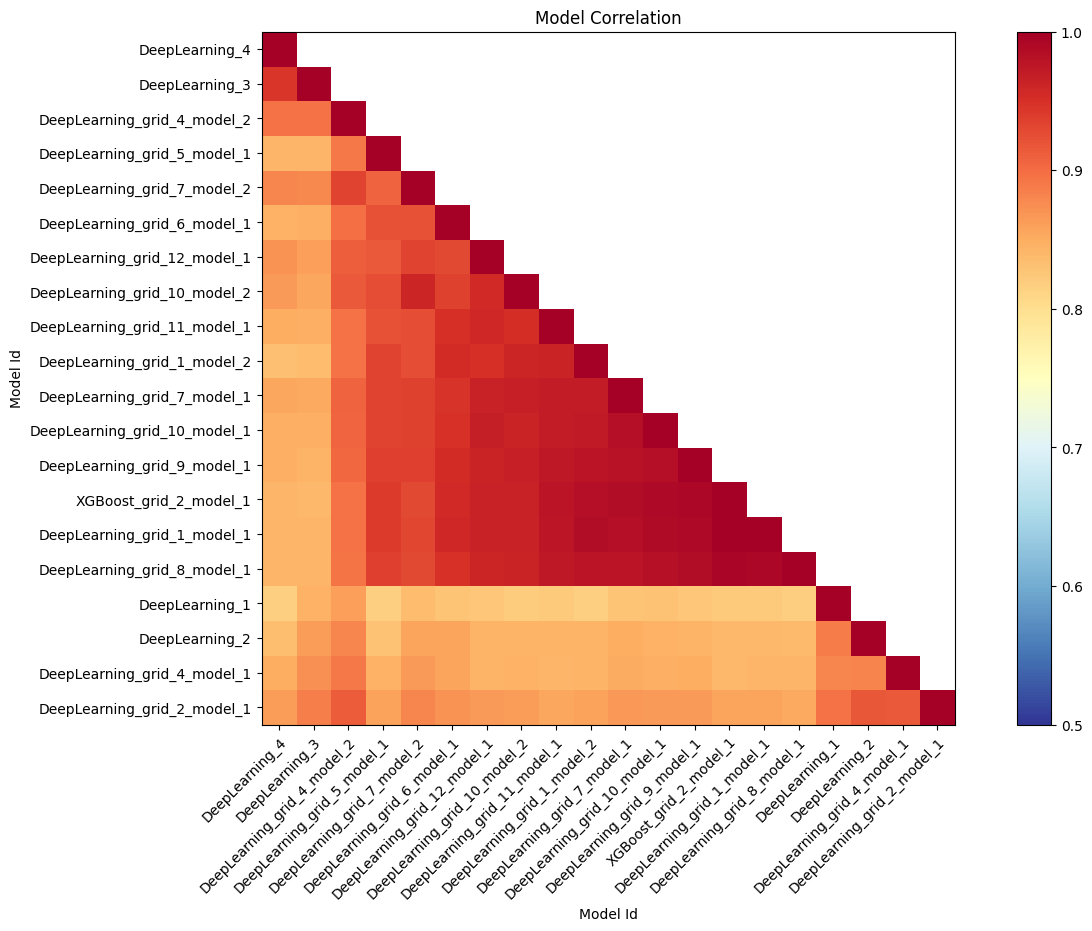

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

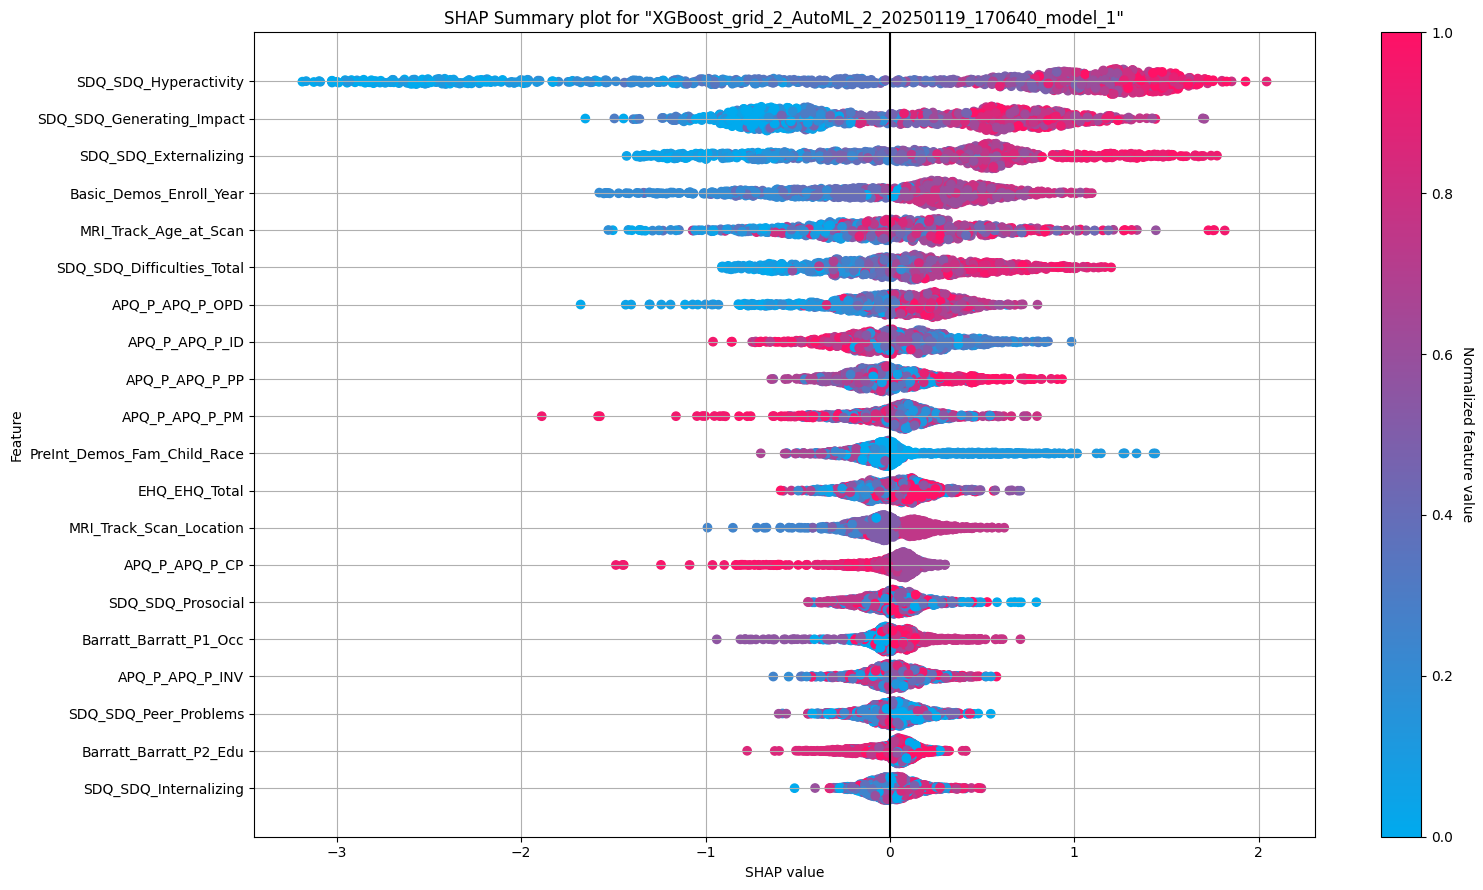

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

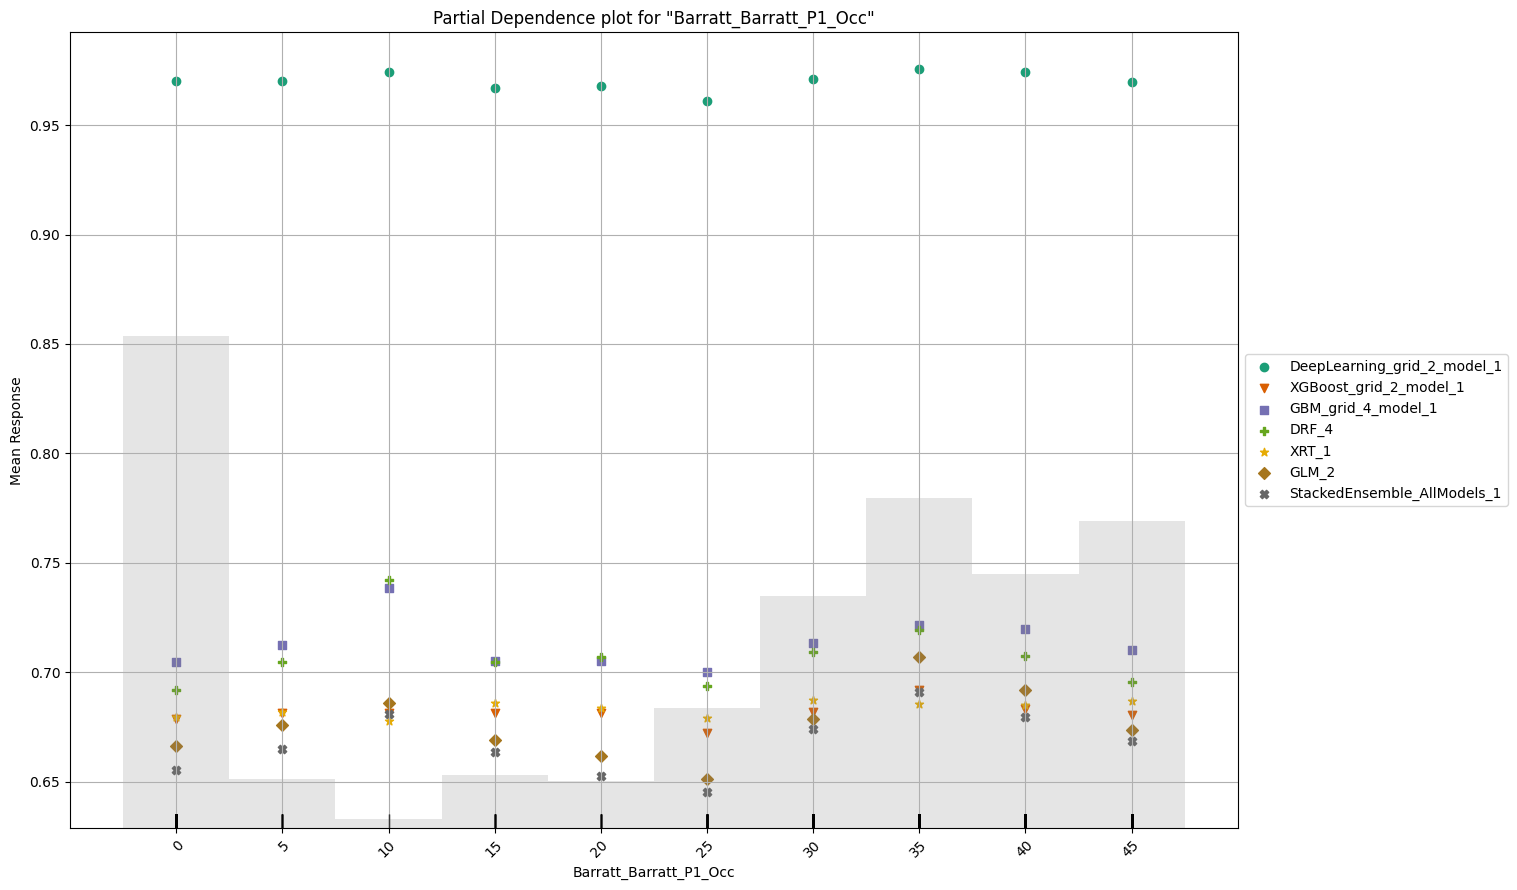

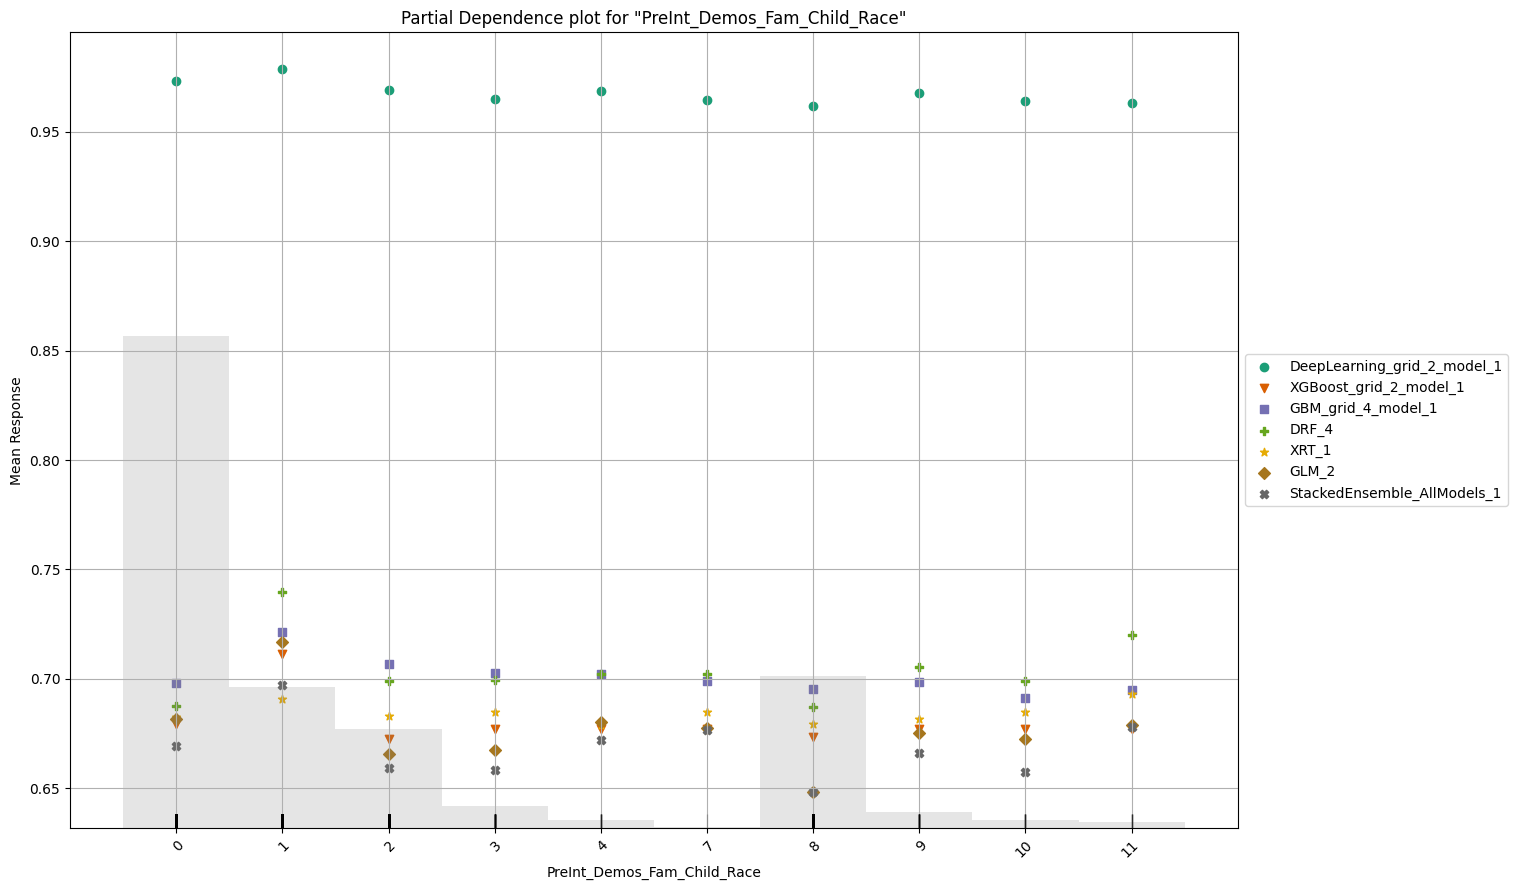

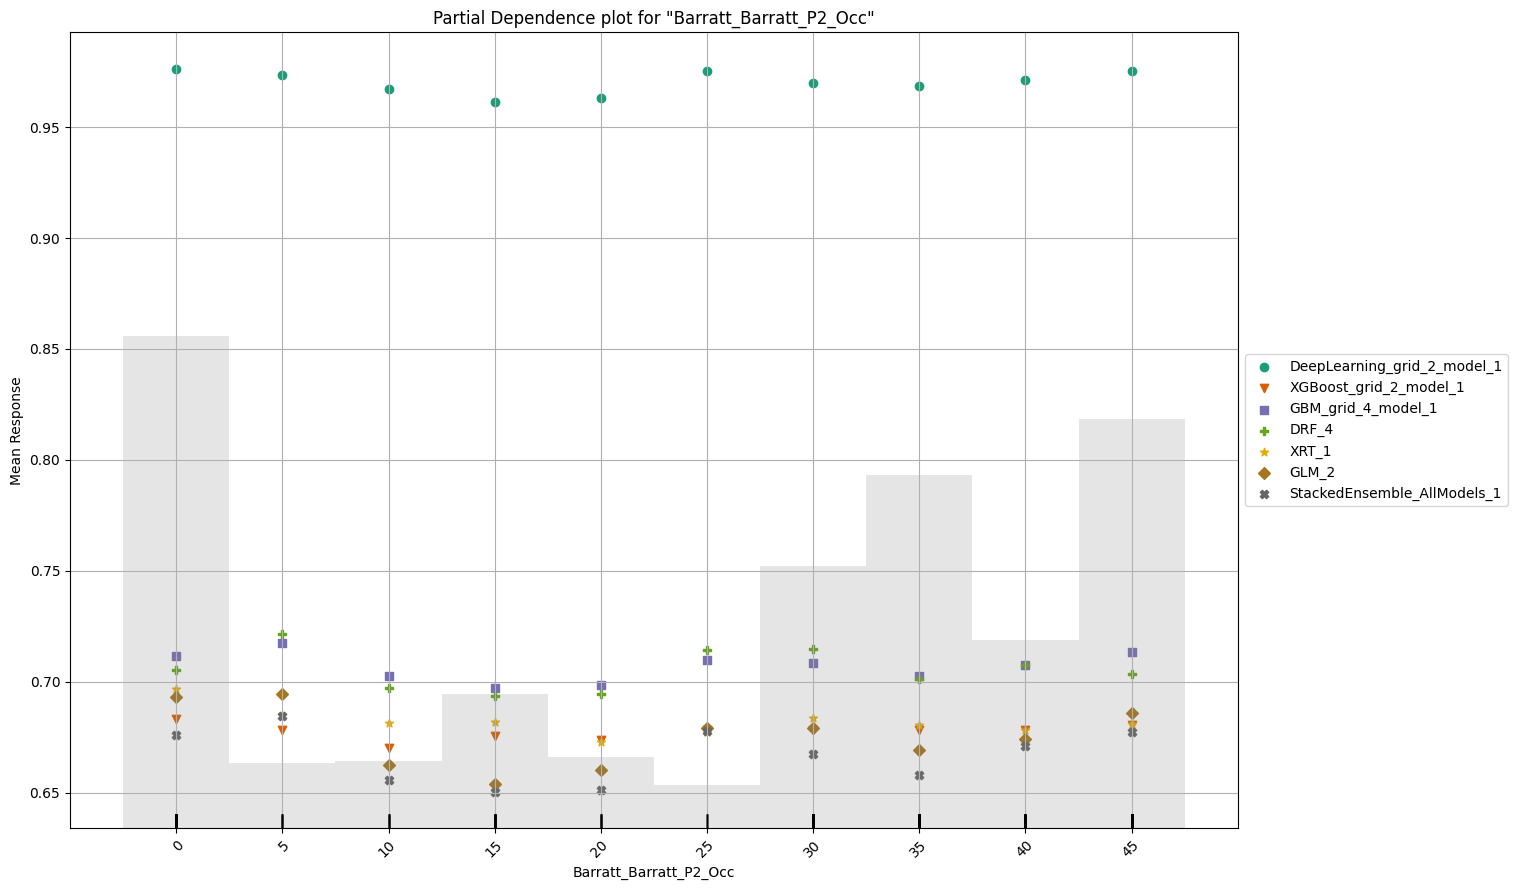

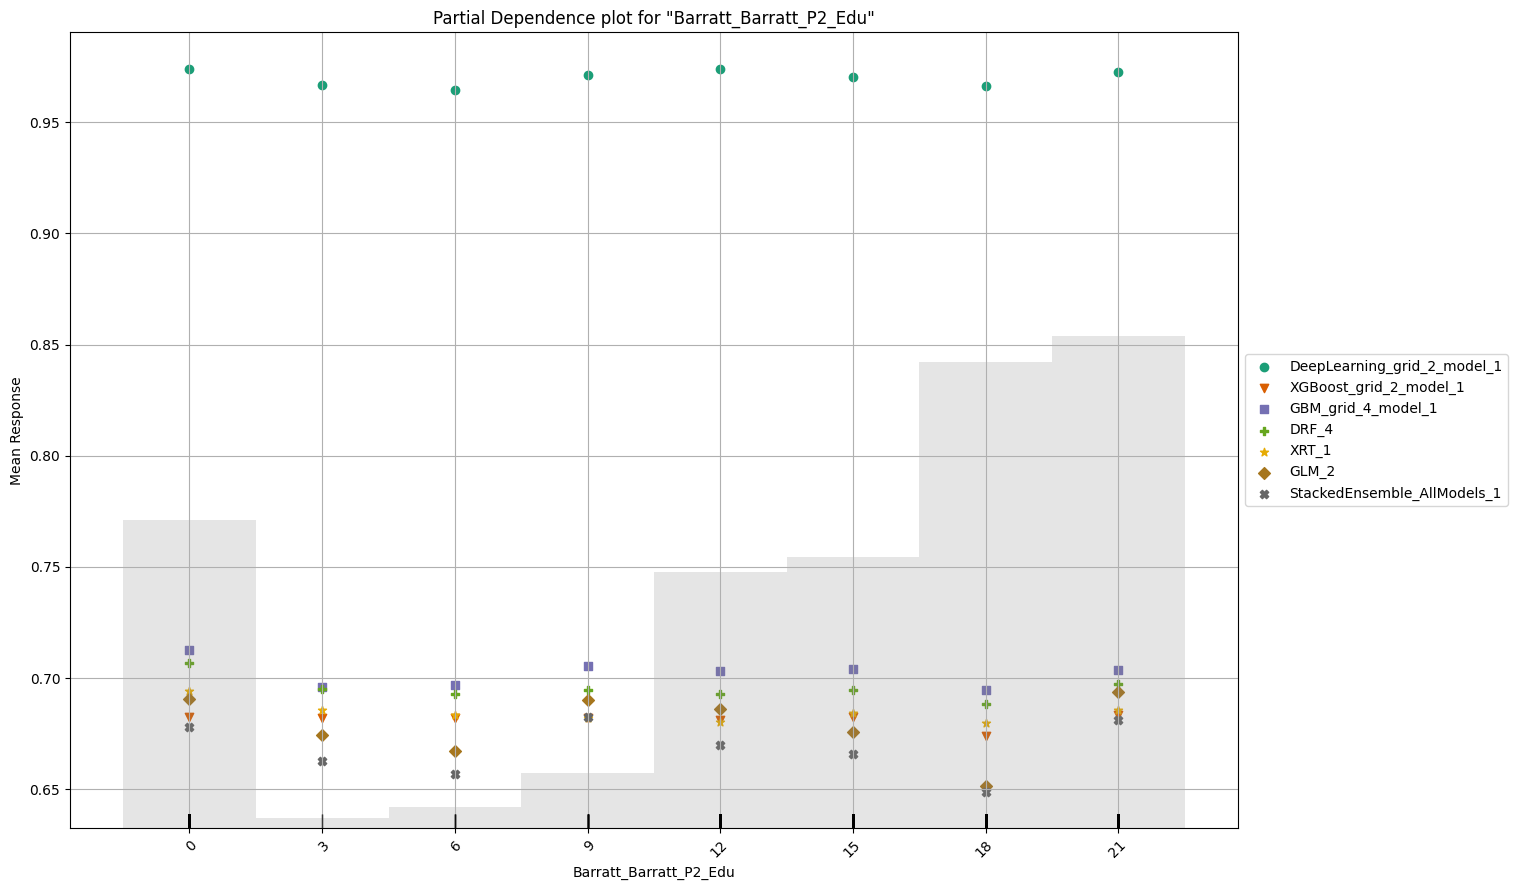

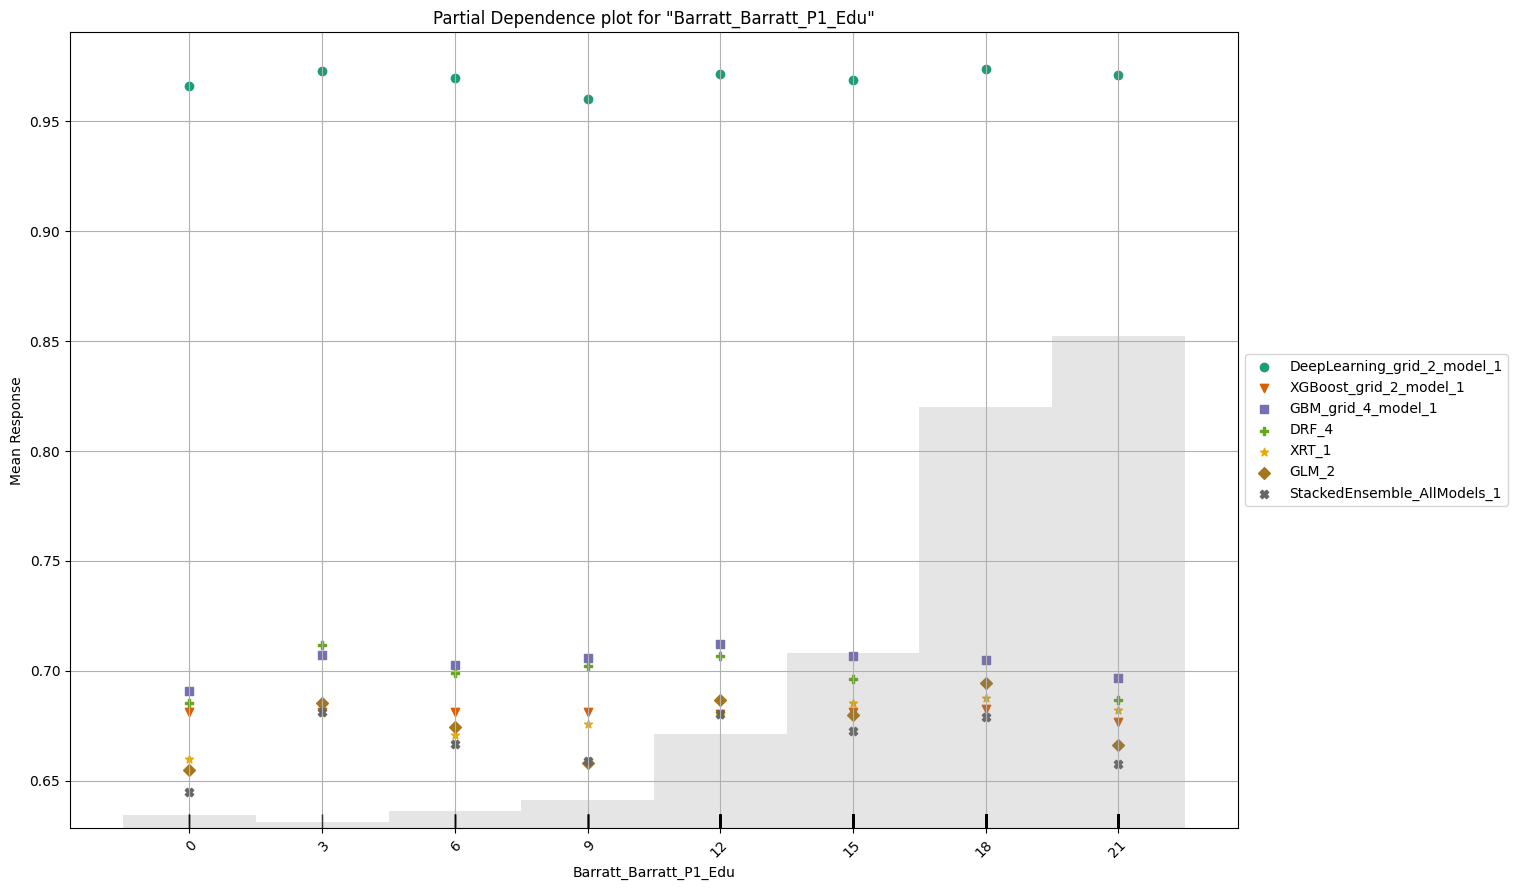

In [14]:
exa = aml.explain(train)
